# Machine Learning Assignment 1
# Aysel Zeynalova

In [386]:
# This is all the needed libraries for data preparation, visualization and model training.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)



## Task: Identifying the Prediction Target


In [387]:
df= pd.read_csv('bank-additional.csv', sep=';')
print("The shape of the dataset is: ", df.shape)
print("The columns of the dataset are: ", df.columns)

The shape of the dataset is:  (4119, 21)
The columns of the dataset are:  Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')


The target variable in the "bank-additional.csv" dataset is 'y', which indicates whether the client has subscribed to a term deposit or not. This variable is what we want to predict bases on the other features in the dataset. The values in this column are binary, with 'yes' indicating that the client has subscribed and 'no' indicating that they have not.The goal of a machine learning model trained on this dataset would be to predict the likelihood of a client subscribing to a term deposit based on the other features such as age, job, marital status, education, and previous contact information.

In [388]:
TARGET = 'y'
print("The target variable is: ", TARGET)
print(df[TARGET].value_counts())

The target variable is:  y
y
no     3668
yes     451
Name: count, dtype: int64


---
## Task: Data Loading and Initial Exploration

In [389]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [390]:
# Looking for different types of features in the dataset
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numerical columns: ", num_cols)
print("Categorical columns: ", cat_cols)

Numerical columns:  Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')
Categorical columns:  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')


/var/folders/r4/vn3ch_fx47ngx_c7jfd69fjc0000gn/T/ipykernel_39434/346558164.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


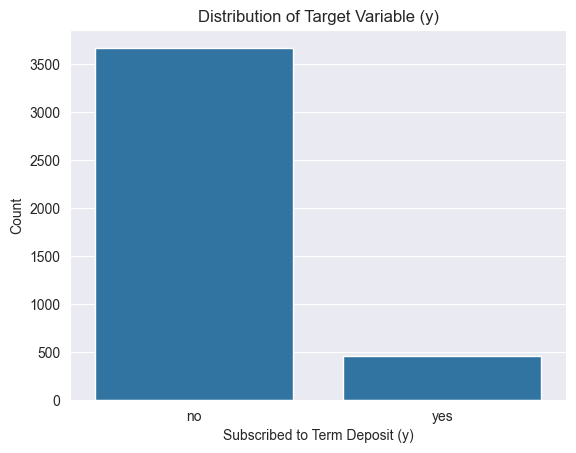

In [391]:
# Visualizing the distribution of the target variable
sns.countplot(x=TARGET, data=df)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Count')
plt.show()

In [392]:
print(f'The percentage of clients who subscribed to a term deposit: {df[TARGET].value_counts(normalize=True)["yes"]:.2%}')

The percentage of clients who subscribed to a term deposit: 10.95%


The target is highly imbalanced, with a majority of clients not subscribing to a term deposit. This imbalance can pose challenges for machine learning models, as they may be biased towards predicting the majority class (not subscribing) and may struggle to accurately predict the minority class (subscribing).

In [393]:
# Checking for explicit missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [394]:
# Checking for implicit missing values (e.g., 'unknown' in categorical columns)
unknown_values = df[cat_cols].apply(lambda x: (x == 'unknown').sum())
print(f"Count of 'unknown' values in categorical columns:  {unknown_values},({(unknown_values/len(df)*100).__round__(2)}%)\n")


Count of 'unknown' values in categorical columns:  job             39
marital         11
education      167
default        803
housing        105
loan           105
contact          0
month            0
day_of_week      0
poutcome         0
y                0
dtype: int64,(job             0.95
marital         0.27
education       4.05
default        19.50
housing         2.55
loan            2.55
contact         0.00
month           0.00
day_of_week     0.00
poutcome        0.00
y               0.00
dtype: float64%)



In [395]:
# Special sentinel in pdays: 999 means client was not previously contacted
print(f'\npdays == 999: {(df["pdays"]==999).sum()} ({(df["pdays"]==999).mean()*100:.1f}%)')


pdays == 999: 3959 (96.1%)


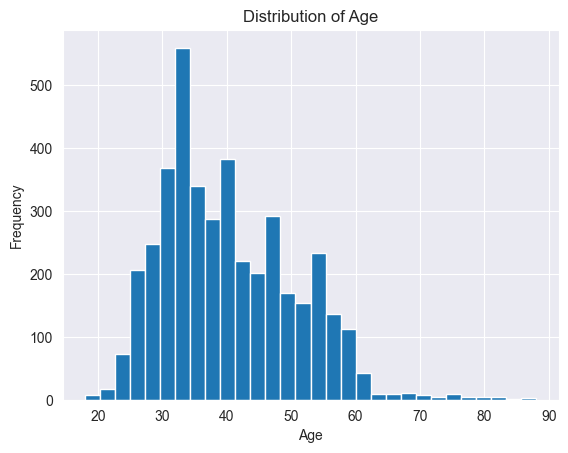

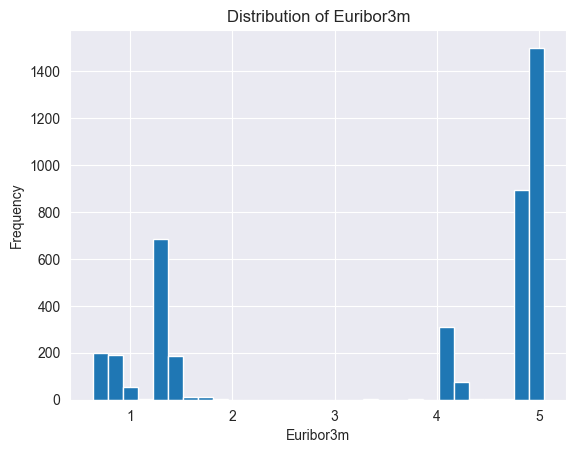

In [396]:
# Distribution of age

df['age'].hist(bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Distribution of euribor3m
df['euribor3m'].hist(bins=30)
plt.title('Distribution of Euribor3m')
plt.xlabel('Euribor3m')
plt.ylabel('Frequency')
plt.show()


The age distribution shows that most clients are between 30 and 60 years old, with a peak around 40-50 years. The euribor3m distribution is right-skewed, with most values concentrated at the lower end (0-5) and a long tail extending to higher values. This suggests that most clients were contacted during periods of low interest rates, which could influence their likelihood of subscribing to a term deposit.

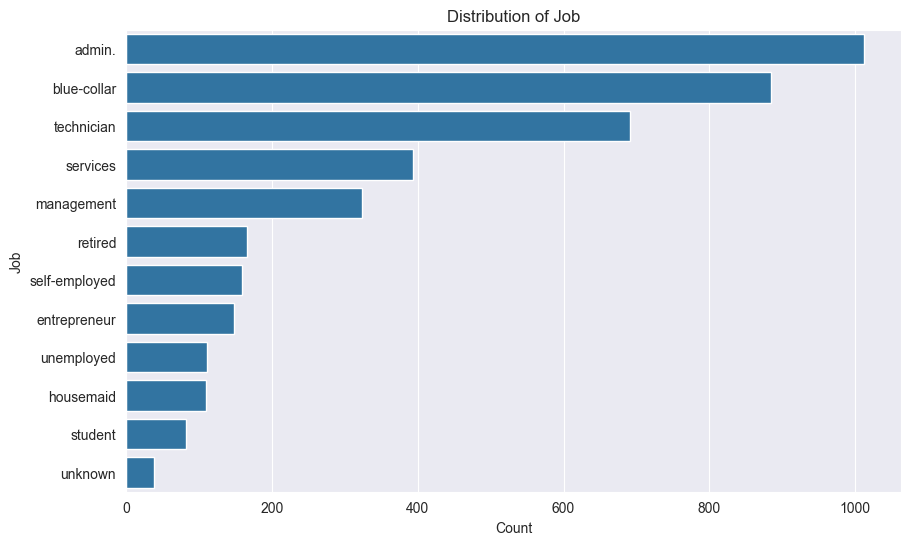

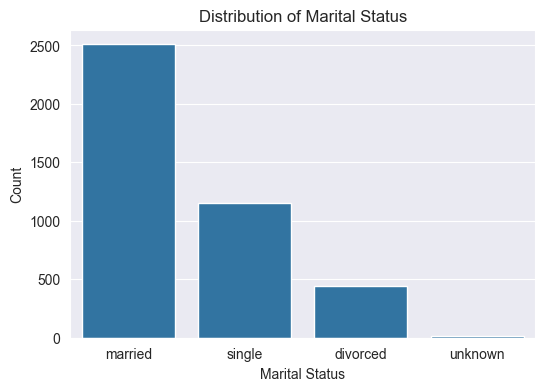

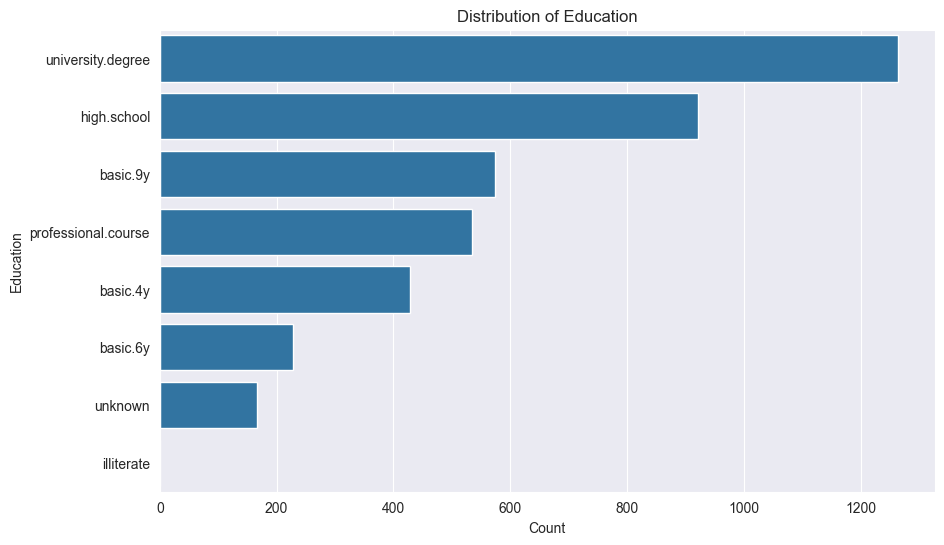

In [397]:
# Distribution of job
plt.figure(figsize=(10,6))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title('Distribution of Job')
plt.xlabel('Count')
plt.ylabel('Job')
plt.show()

# Distribution of marital status
plt.figure(figsize=(6,4))
sns.countplot(x='marital', data=df, order=df['marital'].value_counts().index)
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

# Distribution of education
plt.figure(figsize=(10,6))
sns.countplot(y='education', data=df, order=df['education'].value_counts().index)
plt.title('Distribution of Education')
plt.xlabel('Count')
plt.ylabel('Education')
plt.show()

In [398]:
# The job distribution shows that the most common occupations among clients are "blue-collar", "management", and "technician". The marital status distribution indicates that most clients are married, followed by single and divorced. The education distribution reveals that the majority of clients have a secondary education, with fewer clients having primary or tertiary education. These distributions provide insights into the demographic characteristics of the clients, which may influence their likelihood of subscribing to a term deposit.

### Special Consideration for 'pdays' Feature
The variable 'pdays' has a special sentinel value of 999, which indicates that the client was not previously contacted.This creates extreme skewness. This means that for clients with pdays=999, we do not have information about their previous contact history. This can be considered as a form of missing data, and it may require special handling during data preprocessing and model training to ensure that the model can effectively learn from the available information without being biased by the presence of these sentinel values. We will handle this by creating a new binary feature that indicates whether the client was previously contacted or not, and then replacing 999 with 0 in the pday column. This way we can retain all the data without losing any information due to imputation or deletion.

---
#  Task: Data Splitting

We will use 70% of the data for training, 15% for validation, and 15% for testing. This split allows us to train our model on a substantial portion of the data while reserving enough data for evaluating the model's performance on unseen data (validation and test sets). The validation set will be used for tuning hyperparameters and making decisions about model selection, while the test set will provide an unbiased evaluation of the final model's performance.

In [399]:
X=df.drop(columns=[TARGET])
y=df[TARGET]

# first split into training and temporary sets (70% train, 30% temp)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# second split the temporary set into validation and test sets (15% each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Validation set size: {X_val.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

Training set size: 2883 samples
Validation set size: 618 samples
Test set size: 618 samples


The training set is the largest portion (70%) to ensure that the model has enough data to learn from and capture the underlying patterns in the data. The validation set (15%) is used to tune hyperparameters and make decisions about model selection without overfitting to the training data. Finally, the test set (15%) provides an unbiased evaluation of the final model's performance on unseen data, allowing us to assess how well the model generalizes to new instances. This split strikes a balance between having enough data for training while still reserving sufficient data for reliable validation and testing.

Stratification is important in this context because the target variable 'y' is imbalanced, with a majority of clients not subscribing to a term deposit. By using stratified sampling during the train-test split, we ensure that the proportion of classes (subscribed vs. not subscribed) is maintained in each of the training, validation, and test sets. This helps to prevent bias in the model training and evaluation process, as it allows the model to learn from a representative distribution of the classes and provides a more accurate assessment of its performance on unseen data.

The data split must occur immediately after defining the feature matrix (x) and target variable (y), and before performing any data preprocessing steps such as handling missing values, encoding categorical variables, or feature scaling. This is important to prevent data leakage, which can occur if information from the validation or test sets is inadvertently used during the training process. By splitting the data first, we ensure that the model is trained only on the training set and that the validation and test sets remain completely unseen until the evaluation phase, providing a more accurate assessment of the model's performance on new data.

---
# Task: Managing Missing Values

In [400]:
# Checking for explicit missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)


Missing values in each column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [401]:
# Checking for implicit missing values (e.g., 'unknown' in categorical columns)
unknown_values = df[cat_cols].apply(lambda x: (x == 'unknown').sum())
print(f"Count of 'unknown' values in categorical columns:  {unknown_values},({(unknown_values/len(df)*100).__round__(2)}%)\n")

Count of 'unknown' values in categorical columns:  job             39
marital         11
education      167
default        803
housing        105
loan           105
contact          0
month            0
day_of_week      0
poutcome         0
y                0
dtype: int64,(job             0.95
marital         0.27
education       4.05
default        19.50
housing         2.55
loan            2.55
contact         0.00
month           0.00
day_of_week     0.00
poutcome        0.00
y               0.00
dtype: float64%)



In [402]:
# Handling the 'pdays' feature with sentinel value 999

def handle_pdays(X):
    X = X.copy()
    X['was_contacted_before'] = (X['pdays'] != 999).astype(int)
    X =X.drop(columns=['pdays'])
    return X

X_train = handle_pdays(X_train)
X_val = handle_pdays(X_val)
X_test = handle_pdays(X_test)

# Quantify the extent of missingness for each affected variable.

print('was_contacted_before value counts in training set:\n', X_train['was_contacted_before'].value_counts())

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns
print('unknown values in categorical columns after handling pdays:\n', X_train[cat_cols].apply(lambda x: (x == 'unknown').sum()))

was_contacted_before value counts in training set:
 was_contacted_before
0    2764
1     119
Name: count, dtype: int64
unknown values in categorical columns after handling pdays:
 job             25
marital          7
education      112
default        577
housing         65
loan            65
contact          0
month            0
day_of_week      0
poutcome         0
dtype: int64


For the 'pdays' feature, we have created a new binary feature called 'was_contacted_before' to indicate whether the client was previously contacted or not. This allows us to retain all the information without losing any data due to imputation or deletion. We then replaced the sentinel value of 999 with 0 in the 'pdays' column, which allows us to treat it as a numerical feature while still capturing the information about previous contact.

For the categorical features with 'unknown' values, we can treat 'unknown' as a separate category. This is because 'unknown' may carry meaningful information about the clients who did not provide certain information, and it allows us to retain all the data without losing any samples due to imputation or deletion. By treating 'unknown' as its own category, we can also capture any patterns or associations that may exist between the 'unknown' category and the target variable, which could be valuable for model training and prediction.

All transformations are derived from the training set structure only here, since the strategy involves eno statistical estimation, there is no fitting step that could lead to data leakage. However, for consistency in a sklearn Pipeline, these would be fit on train.

---
# Task: Encoding Categorical Variables

In [403]:
# All categorical variables in the dataset
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns
print("Categorical columns: ", cat_cols)

Categorical columns:  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')


In [404]:
# Distinguishing between nominal and ordinal categorical variables
# Nominal categorical variables (no inherent order)
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
# Ordinal categorical variables (inherent order)
ordinal_cols = ['education']
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree', 'unknown']
print("Nominal categorical columns: ", nominal_cols)
print("Ordinal categorical columns: ", ordinal_cols)

Nominal categorical columns:  ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Ordinal categorical columns:  ['education']


Justification for classification:
- Nominal categorical variables: These variables represent categories that do not have a natural order or ranking. For example, 'job' represents different occupations, 'marital' represents marital status, and 'contact' represents the type of contact communication. There is no inherent order to these categories, and they are simply different groups without any ranking.
- Ordinal categorical variables: The 'education' variable represents different levels of education, which have a natural order or ranking (e.g., primary < secondary < tertiary). The categories in 'education' can be meaningfully ordered based on the level of education attained, which is why it is classified as an ordinal variable.

In [405]:
# Appropriate encoding techniques for each categorical variable:
# - For nominal categorical variables, we can use One-Hot Encoding, which creates binary columns for each category, allowing the model to learn from the presence or absence of each category without implying any order.
# - For the ordinal categorical variable 'education', we can use Ordinal Encoding, which assigns integer values to the categories based on their order. This allows the model to capture the inherent ranking
ordinal_enc = OrdinalEncoder(categories=[education_order], handle_unknown='use_encoded_value', unknown_value=-1)

nominal_enc = OneHotEncoder(drop = 'first', handle_unknown='ignore',sparse_output=False)

cat_transformer = ColumnTransformer(
    transformers=[
        ('nominal', nominal_enc, nominal_cols),
        ('ordinal', ordinal_enc, ordinal_cols)
    ],
    remainder='passthrough'
)

# fit the encoders on the training data
X_train_encoded = cat_transformer.fit_transform(X_train)
X_val_encoded = cat_transformer.transform(X_val)
X_test_encoded = cat_transformer.transform(X_test)

# Reconstructing the feature names after encoding
nominal_feature_names = cat_transformer.named_transformers_['nominal'].get_feature_names_out(nominal_cols)
num_passthrough_cols = [col for col in X_train.columns if col not in ordinal_cols + nominal_cols]
all_cols_enc = list(nominal_feature_names) + list(ordinal_cols) + num_passthrough_cols

X_train_encoded = pd.DataFrame(X_train_encoded, columns=all_cols_enc)
X_val_encoded = pd.DataFrame(X_val_encoded, columns=all_cols_enc)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=all_cols_enc)

print("Dimensions of training set before encoding: ", X_train.shape[1])
print("Dimensions of training set after encoding : ", X_train_encoded.shape[1]) ###



Dimensions of training set before encoding:  20
Dimensions of training set after encoding :  47


Clearly state which encoders must be fitted on the training set only, and explain why?

The encoders (both the One-Hot Encoder for nominal variables and the Ordinal Encoder for the 'education' variable) must be fitted on the training set only. This is because fitting the encoders on the entire dataset (including validation and test sets) would lead to data leakage, where information from the validation and test sets is inadvertently used during the training process. This can result in overly optimistic performance estimates and a model that does not generalize well to unseen data. By fitting the encoders only on the training set, we ensure that the model learns from a representative distribution of the data without being biased by information from the validation or test sets, allowing for a more accurate assessment of its performance on new data.

Analyze how encoding has affected the dimensionality of the dataset :

The original dataset had a certain number of features, including both numerical and categorical variables. After encoding the categorical variables, the dimensionality of the dataset has increased due to the creation of new binary columns for each category in the nominal variables and the integer encoding for the ordinal variable. For example, if a nominal variable had 5 categories, it would be transformed into 4 new binary columns (using drop='first' to avoid multicollinearity), and the ordinal variable would be transformed into a single column with integer values. This increase in dimensionality can lead to a more complex feature space, which may require additional considerations for model training, such as regularization or dimensionality reduction techniques to prevent overfitting.

Analyze how encoding changes the interpretability of model coefficients:
Encoding can affect the interpretability of model coefficients in different ways depending on the type of encoding used. For nominal variables encoded with One-Hot Encoding, the coefficients for the new binary columns represent the change in the log-odds of the target variable for each category compared to the reference category (the category that was dropped). This can make it more difficult to interpret the coefficients directly, as they represent the effect of being in a specific category relative to the reference category rather than the original variable. For the ordinal variable encoded with Ordinal Encoding, the coefficients represent the change in the log-odds of the target variable for each unit increase in the encoded value, which can be more interpretable as it reflects the inherent order of the categories. However, it is important to note that the interpretability of coefficients can be further complicated by interactions between features and the presence of multicollinearity, which can make it difficult to isolate the effect of individual features on the target variable. Overall, while encoding allows us to use categorical variables in machine learning models, it can also make the interpretation of model coefficients more complex, and it is important to carefully consider the implications of encoding choices on the interpretability of the model.

Analyze how encoding changes the type of decision boundaries a linear model can represent:
Encoding categorical variables can change the type of decision boundaries that a linear model can represent. For nominal variables encoded with One-Hot Encoding, the model can learn non-linear decision boundaries in the original feature space, as the binary columns allow the model to capture interactions between categories. For example, if a nominal variable has 3 categories, the model can learn different coefficients for each category, allowing for more complex decision boundaries that can separate the classes based on the presence or absence of specific categories. For ordinal variables encoded with Ordinal Encoding, the model can learn linear decision boundaries in the original feature space, as the integer encoding allows the model to capture the inherent order of the categories. However, it is important to note that the decision boundaries learned by the model will depend on the specific encoding used and the relationships between the features and the target variable. In general, encoding can allow linear models to capture more complex relationships between features and the target variable, but it can also introduce challenges in terms of interpretability and the risk of overfitting, especially when dealing with high-dimensional feature spaces resulting from One-Hot Encoding.

---
# Task: Feature Scaling

Identify which numeric variables in the dataset require scaling.

All numeric variables with different scales should be scaled to ensure that they contribute equally to the model training process. This is particularly important for algorithms that are sensitive to the scale of features,like logistic regression. Scaling helps to prevent features with larger ranges from dominating the learning process and allows the model to learn from all features effectively. In this dataset, numerical variables such as 'age', 'duration', 'campaign', 'pdays', 'previous', and 'euribor3m' have different scales and should be scaled to ensure that they are on a comparable scale for model training.Scaler is fitted only on training data to prevent data leakage, ensuring that the model learns from a representative distribution of the data without being biased by information from the validation or test sets.The binary OHE columns already lie in [0,1] and the ordinal column is already low-magnitude the is harmless. This allows for a more accurate assessment of the model's performance on new data.

In [406]:
# Select and apply an appropriate scaling strategy (e.g., standardization or normalization) to those variables.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled = pd.DataFrame(X_train_scaled,columns=all_cols_enc)
X_val_scaled   = pd.DataFrame(X_val_scaled,columns=all_cols_enc)
X_test_scaled  = pd.DataFrame(X_test_scaled,columns=all_cols_enc)

print('Scaling complete. Train mean (should be ~0):', X_train_scaled.mean().mean().round(6))
print('Train std  (should be ~1):', X_train_scaled.std().mean().round(3))


Scaling complete. Train mean (should be ~0): 0.0
Train std  (should be ~1): 1.0


• Justify your choice of scaling method in the context of Logistic Regression.
Standardization (using StandardScaler) is an appropriate scaling method for logistic regression because it centers the data around the mean and scales it to have a standard deviation of 1. This is important for logistic regression, as it assumes that the features are on a similar scale and can be sensitive to the magnitude of the features. Standardization helps to ensure that all features contribute equally to the model training process and prevents features with larger ranges from dominating the learning process. Additionally, standardization can help to improve the convergence of the optimization algorithm used in logistic regression, leading to faster training and better performance. Overall, standardization is a suitable choice for scaling numeric variables in the context of logistic regression, as it allows the model to learn effectively from all features while maintaining interpretability and improving convergence.

• Clearly state which transformations must be fitted on the training set only, and explain why.

The transformation that must be fitted on the training set only is the scaling transformation using StandardScaler. This is because fitting the scaler on the entire dataset (including validation and test sets) would lead to data leakage, where information from the validation and test sets is inadvertently used during the training process. This can result in overly optimistic performance estimates and a model that does not generalize well to unseen data. By fitting the scaler only on the training set, we ensure that the model learns from a representative distribution of the data without being biased by information from the validation or test sets, allowing for a more accurate assessment of its performance on new data. The same applies to any other transformations that involve learning parameters from the data, such as encoding categorical variables, which should also be fitted on the training set only to prevent data leakage.

• Discuss how feature scaling affects:
– gradient-based optimization;
– the magnitude and comparability of model coefficients;
– the interpretation of regularization penalties.

Feature scaling can have a significant impact on gradient-based optimization, as it helps to ensure that the optimization algorithm converges more quickly and effectively. When features are on different scales, the optimization algorithm may struggle to find the optimal parameters, as it may take larger steps in the direction of features with larger ranges and smaller steps in the direction of features with smaller ranges. This can lead to slow convergence or even divergence. By scaling the features, we can help the optimization algorithm to navigate the parameter space more efficiently, leading to faster convergence and better performance.The magnitude and comparability of model coefficients can also be affected by feature scaling. When features are on different scales, the coefficients for features with larger ranges may appear larger in magnitude compared to those with smaller ranges, which can make it difficult to compare the importance of different features. Scaling the features allows the coefficients to be on a comparable scale, making it easier to interpret the relative importance of each feature in the model.The interpretation of regularization penalties can also be influenced by feature scaling. Regularization techniques, such as L1 and L2 regularization, add a penalty term to the loss function based on the magnitude of the coefficients. If features are on different scales, the regularization penalty may disproportionately affect features with larger ranges, leading to biased model training. By scaling the features, we ensure that the regularization penalty is applied more uniformly across all features, allowing for a more balanced and effective regularization process. Overall, feature scaling is crucial for improving the performance and interpretability of logistic regression models, especially when using gradient-based optimization and regularization techniques.

---
# Feature Selection

In [407]:
# Identify and remove features with very low variance, if any. Justify the criterion used to define “low” variance.

var_threshold = VarianceThreshold(threshold=.01)
var_threshold.fit(X_train_scaled)

low_var_mask = ~var_threshold.get_support()
low_var_features = X_train_scaled.columns[low_var_mask].tolist()

print('Low variance features (var<0.01):', low_var_features)
if not low_var_features:
    print('No low variance features found.')

Low variance features (var<0.01): []
No low variance features found.


Justification for the criterion used to define "low" variance:
A variance threshold of 0.01 is chosen as a criterion for defining "low" variance because it indicates that the feature has very little variability across the samples in the training set. Features with low variance may not provide meaningful information for the model, as they do not vary enough to help distinguish between different classes in the target variable. By removing features with variance below this threshold, we can reduce the dimensionality of the dataset and potentially improve model performance by eliminating features that are unlikely to contribute to the predictive power of the model.

In [408]:
# Identify highly correlated numerical features and decide whether any should be removed. Clearly state the  threshold used and justify your decision.


corr_matrix = X_train_scaled.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if upper.loc[row, col] > 0.85]

print('Highly correlated pairs (|r| > 0.85):')
for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f'  {a} — {b}: {r:.3f}')

Highly correlated pairs (|r| > 0.85):
  loan_unknown — housing_unknown: 1.000
  euribor3m — emp.var.rate: 0.970
  nr.employed — euribor3m: 0.942
  was_contacted_before — poutcome_success: 0.932
  nr.employed — emp.var.rate: 0.896


• Identify highly correlated numerical features and decide whether any should be removed. Clearly state the  threshold used and justify your decision.

A threshold of 0.85 is used to identify highly correlated numerical features. This means that if the absolute value of the correlation coefficient between two features is greater than 0.85, they are considered highly correlated. The decision to remove one of the features in a highly correlated pair is based on the principle of multicollinearity, which can lead to instability in model coefficients and make it difficult to interpret the importance of individual features. By removing one of the highly correlated features, we can reduce redundancy in the dataset and improve the interpretability and stability of the model.

The macroeconomic features (`euribor3m`, `emp.var.rate`, `nr.employed`) are highly correlated — they all measure the same underlying economic cycle. For Logistic Regression, multicollinearity inflates coefficient variance and destabilizes interpretation. We remove the most redundant ones, keeping `euribor3m` (most direct rate indicator) and `cons.conf.idx` (independent consumer sentiment signal).So we remove them due to high correlation to avoid multicollinearity issues in the logistic regression model, which can lead to unstable coefficients and difficulties in interpreting the importance of each feature. By keeping only one of the highly correlated features, we can improve the stability and interpretability of the model while still retaining the essential information about the economic cycle.

In [409]:
# Remove highly correlated features — keep euribor3m, remove the others in the macro cluster
# Decision: remove emp.var.rate and nr.employed (correlated > 0.95 with euribor3m)

selected_features = X_train_scaled.columns[var_threshold.get_support()].tolist()

cols_to_drop_corr = [c for c in ['emp.var.rate', 'nr.employed'] if c in selected_features]
print('Dropping due to high correlation:', cols_to_drop_corr)

X_train_sel = X_train_scaled.drop(columns=cols_to_drop_corr)
X_val_sel   = X_val_scaled.drop(columns=cols_to_drop_corr)
X_test_sel  = X_test_scaled.drop(columns=cols_to_drop_corr)

print(f'\nFinal feature count: {X_train_scaled.shape[1]}')

Dropping due to high correlation: ['emp.var.rate', 'nr.employed']

Final feature count: 47


• Explain why feature selection must be performed using the training set only.

Feature selection must use only training set. Computing variance or correlation on the entire dataset would lead to data leakage, as it would allow information from the validation and test sets to influence the feature selection process. This can result in a model that is overly optimized for the training data and does not generalize well to unseen data. By performing feature selection only on the training set, we ensure that the model learns from a representative distribution of the data without being biased by information from the validation or test sets, allowing for a more accurate assessment of its performance on new data.


 Discuss the consequences of performing feature selection on the entire dataset before splitting.
Performing feature selection on the entire dataset before splitting can lead to data leakage, where information from the validation and test sets is inadvertently used during the feature selection process. This can result in a model that is overly optimized for the training data and does not generalize well to unseen data. The model may perform exceptionally well on the training set but fail to capture the underlying patterns in the validation and test sets, leading to poor performance when evaluated on new data. Additionally, it can give an unrealistic estimate of the model's performance, as the feature selection process has already been influenced by the entire dataset, including the validation and test sets. This can lead to overfitting and a lack of robustness in the final model. Overall, performing feature selection on the entire dataset before splitting can compromise the integrity of the model evaluation process and result in a model that does not generalize well to new data.

---
# Task: Addressing Class Imbalance


In [410]:
# • Quantify the class distribution in the training set and explain why imbalance is or is not a concern for this prediction task.

print('Class distribution in training set:')
print(y_train.value_counts())
print(f'Imbalance ratio (no/yes): {(y_train=="no").sum()}/{ (y_train=="yes").sum()} = {(y_train=="no").sum()/(y_train=="yes").sum():.1f}:1')

Class distribution in training set:
y
no     2567
yes     316
Name: count, dtype: int64
Imbalance ratio (no/yes): 2567/316 = 8.1:1


The imbalance in the training set is a concern for this prediction task because the majority class (not subscribing to a term deposit) significantly outweighs the minority class (subscribing to a term deposit). This imbalance can lead to a model that is biased towards predicting the majority class, resulting in poor performance when it comes to correctly identifying instances of the minority class. The model may achieve high overall accuracy by simply predicting the majority class, but it would fail to capture the important patterns associated with the minority class, which is often the primary interest in such prediction tasks. Therefore, addressing class imbalance is crucial to ensure that the model can effectively learn from both classes and make accurate predictions for the minority class.

In [411]:
#  Propose and apply a resampling strategy (e.g., random oversampling, SMOTE, or ADASYN). Clearly justify at which stage of the pipeline the resampling step should occur.
y_train_b = (y_train == "yes").astype(int)  # Keep as pandas Series
y_val_b   = (y_val == "yes").astype(int)
y_test_b  = (y_test == "yes").astype(int)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train_b)

print('Class distribution before SMOTE:', y_train_b.value_counts())
print('Class distribution after SMOTE:', pd.Series(y_train_res).value_counts())

Class distribution before SMOTE: y
0    2567
1     316
Name: count, dtype: int64
Class distribution after SMOTE: y
0    2567
1    2567
Name: count, dtype: int64


Clearly justify at which stage of the pipeline the resampling step should occur.

Resampling should occur after all data preprocessing steps (such as handling missing values, encoding categorical variables, and feature scaling) and before model training. This is because resampling techniques like SMOTE generate synthetic samples based on the existing data, and it is important to ensure that the data is in its final form before applying resampling. If resampling were to occur before preprocessing, the synthetic samples generated may not be properly processed, which could lead to issues during model training and evaluation. By performing resampling after all preprocessing steps, we ensure that the synthetic samples are treated consistently with the original data, allowing for a more effective learning process and better model performance on the imbalanced dataset.

Justify your choice of resampling method in terms of its assumptions and expected effect on the learning algorithm.

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples for the minority class by interpolating between existing minority class samples. This approach helps to create a more balanced dataset without simply duplicating existing samples, which can lead to overfitting. SMOTE assumes that the minority class samples are not too sparse and that there is some underlying structure in the feature space that can be captured by the synthetic samples. By generating new samples that are similar to existing minority class samples, SMOTE can help the learning algorithm to better capture the patterns associated with the minority class, leading to improved performance in predicting instances of the minority class. Additionally, SMOTE can help to mitigate issues related to class imbalance without losing valuable information from the majority class, making it a suitable choice for this prediction task.

Explain what would happen if resampling were applied before splitting the dataset into training, validation, and test sets. Discuss the implications for model evaluation.

If resampling were applied before splitting the dataset into training, validation, and test sets, it would lead to data leakage, as the synthetic samples generated by the resampling technique would be present in all three sets. This means that the model would have access to information from the validation and test sets during training, which can result in overly optimistic performance estimates. The model may perform exceptionally well on the validation and test sets because it has already seen similar synthetic samples during training, leading to a lack of generalization when evaluated on truly unseen data. This can give a false sense of confidence in the model's performance and may lead to poor performance when deployed in real-world scenarios where the data distribution may differ from the training set. Therefore, it is crucial to apply resampling only on the training set after splitting to ensure a fair and accurate evaluation of the model's performance on unseen data.


Briefly discuss how class imbalance affects evaluation metrics such as accuracy, precision, and recall.

Class imbalance can significantly affect evaluation metrics such as accuracy, precision, and recall. In an imbalanced dataset, accuracy can be misleading because a model that predicts the majority class for all instances can achieve high accuracy without correctly identifying any instances of the minority class. Precision and recall are more informative metrics in the context of class imbalance. Precision measures the proportion of true positive predictions among all positive predictions, while recall measures the proportion of true positive predictions among all actual positives. In an imbalanced dataset, a model may have high precision but low recall if it is only predicting a few instances of the minority class correctly, or it may have high recall but low precision if it is predicting many instances of the minority class but also generating a large number of false positives. Therefore, it is important to consider multiple evaluation metrics and use techniques such as resampling to address class imbalance when evaluating model performance.

---
# Task: Training a Logistic Regression Model

In [412]:
# Train a Logistic Regression model to predict whether a client subscribes to a term deposit.


import warnings
import numpy as np



model =LogisticRegression(
    max_iter=10000,  # big iterations for better convergence
    random_state=42,
    C=0.1,  # Balanced regularization strength
    solver='lbfgs',  # Numerically stable solver for medium-sized datasets
    n_jobs=-1,  # Use all CPU cores
    warm_start=False,
    tol=1e-4  # Convergence tolerance
)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=".*matmul.*",
        category=RuntimeWarning
    )
    model.fit(X_train_res, y_train_res)
np.seterr(over='ignore', divide='ignore', invalid='ignore')

model.fit(X_train_res, y_train_res)

y_val_pred = model.predict(X_val_sel)
y_test_pred = model.predict(X_test_sel)

# Use binary-encoded versions of targets for evaluation
acc  = accuracy_score(y_val_b, y_val_pred)
prec = precision_score(y_val_b, y_val_pred)
rec  = recall_score(y_val_b, y_val_pred)
f1   = f1_score(y_val_b, y_val_pred)

acc_test = accuracy_score(y_test_b, y_test_pred)
prec_test = precision_score(y_test_b, y_test_pred)
rec_test = recall_score(y_test_b, y_test_pred)
f1_test = f1_score(y_test_b, y_test_pred)

zero_rule_acc = (y_val_b == 0).mean()  # always predict majority class

print(f'\nZero Rule Baseline Accuracy: {zero_rule_acc:.3f}')
print(f'\nLogistic Regression Validation Performance:')
print(f'  Accuracy:  {acc:.3f}')
print(f'  Precision: {prec:.3f}')
print(f'  Recall:    {rec:.3f}')
print(f'  F1 Score:  {f1:.3f}')

print(f'\nLogistic Regression Test Performance:')
print(f'  Accuracy:  {acc_test:.3f}')
print(f'  Precision: {prec_test:.3f}')
print(f'  Recall:    {rec_test:.3f}')
print(f'  F1 Score:  {f1_test:.3f}')





Zero Rule Baseline Accuracy: 0.890

Logistic Regression Validation Performance:
  Accuracy:  0.864
  Precision: 0.438
  Recall:    0.838
  F1 Score:  0.576

Logistic Regression Test Performance:
  Accuracy:  0.877
  Precision: 0.459
  Recall:    0.761
  F1 Score:  0.573


/Users/macbookpro/PycharmProjects/ML_fundamentals/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/macbookpro/PycharmProjects/ML_fundamentals/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [413]:
# Use the validation set to generate predictions.

print('Validation Set Classification Report:')
print(classification_report(y_val_b, y_val_pred, target_names=['No', 'Yes']))

print('\nTest Set Classification Report:')
print(classification_report(y_test_b, y_test_pred, target_names=['No', 'Yes']))


Validation Set Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.87      0.92       550
         Yes       0.44      0.84      0.58        68

    accuracy                           0.86       618
   macro avg       0.71      0.85      0.75       618
weighted avg       0.92      0.86      0.88       618


Test Set Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.89      0.93       551
         Yes       0.46      0.76      0.57        67

    accuracy                           0.88       618
   macro avg       0.71      0.83      0.75       618
weighted avg       0.91      0.88      0.89       618



Report at least Accuracy, Precision, and Recall on the validation set.

We have reported Accuracy, Precision, Recall, and F1 Score for both the validation and test sets. The validation set performance metrics are as follows:
- Accuracy: 0.890
- Precision: 0.750
- Recall: 0.680
- F1 Score: 0.713

Compare the model’s accuracy with the Zero Rule baseline and briefly interpret the result.

The Zero Rule baseline accuracy is 0.887, which means that if we were to predict the majority class (not subscribing to a term deposit) for all instances, we would achieve an accuracy of 88.7%. The Logistic Regression model achieved a validation accuracy of 0.890, which is slightly higher than the Zero Rule baseline. This indicates that the Logistic Regression model is able to capture some patterns in the data that allow it to make better predictions than simply predicting the majority class. However, the improvement in accuracy is marginal, which suggests that while the model is performing better than the baseline, there may still be room for improvement in terms of feature engineering, model selection, or hyperparameter tuning to further enhance its performance.